<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. This exercise focus on identifying and removing duplicate entries from dataset. 


## Objectives


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 138.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



In [6]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [20]:
#sum
dupp = df.duplicated().sum()
print("count of duplicate columns", dupp)

df[df.duplicated()].head()

count of duplicate columns 0

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


In [23]:
pattern_counts = (
    df.groupby(["Employment", "RemoteWork"])
      .size()
      .sort_values(ascending=False)
)

pattern_counts.head()

Employment                                                                RemoteWork                          
Employed, full-time                                                       Hybrid (some remote, some in-person)    17281
                                                                          Remote                                  13193
                                                                          In-person                                8552
Independent contractor, freelancer, or self-employed                      Remote                                   3230
Employed, full-time;Independent contractor, freelancer, or self-employed  Remote                                   1861
dtype: int64

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [29]:

pattern_counts = (
    df.groupby(["MainBranch", "Employment", "RemoteWork"])
      .size()
      .sort_values(ascending=False)
)

print(pattern_counts.head())

MainBranch                      Employment                                                                RemoteWork                          
I am a developer by profession  Employed, full-time                                                       Hybrid (some remote, some in-person)    15286
                                                                                                          Remote                                  12191
                                                                                                          In-person                                7118
                                Independent contractor, freelancer, or self-employed                      Remote                                   2814
                                Employed, full-time;Independent contractor, freelancer, or self-employed  Remote                                   1754
dtype: int64

In [34]:
#col3= df[df[["MainBranch","Employment","RemoteWork"]].duplicated()].head()
#col3.head()
#col4 = df[["MainBranch","Employment","RemoteWork"]]
#dupp_col4 = col4.duplicated()
#df.duplicated(subset= ["MainBranch","Employment","RemoteWork"]).sum()
df[df.duplicated(subset= ["MainBranch","Employment","RemoteWork"], keep=False)].sort_values(by=["MainBranch","Employment","RemoteWork"]).head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
12,13,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,NaN,...,30.0,0.0,0.0,20.0,10.0,10.0,Appropriate in length,Easy,NaN,8.0
14,15,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Coding sessions (live or record...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
15,16,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,5.0


In [42]:
summary = (
    df.groupby(["MainBranch", "Employment", "RemoteWork"])
      .nunique()

)
(summary == 1).sum().sort_values(ascending=False)

Check                         449
SOAccount                     193
AISelect                      191
AIThreat                      179
SurveyLength                  176
                             ... 
YearsCodePro                   63
TechEndorse                    63
AINextMuch less integrated     61
CompTotal                      55
ConvertedCompYearly            51
Length: 111, dtype: int64

In [56]:
#pattern_groups= df.groupby(["MainBranch","Employment","RemoteWork"]).size().reset_index(name = "Respondents").sort_values("Respondents",ascending=False)
#pattern_groups.head()
#type(pattern_groups)

#group = df[(df["MainBranch"] == "Developer") & (df["Employment"] == "Employed, full-time") & (df["RemoteWork"] == "Remote")]
#group.head()
#group.nunique().sort_values()

patt= df.groupby(["MainBranch", "Employment", "RemoteWork"]).nunique()
patt.head()


ResponseId  \
MainBranch                     Employment                              RemoteWork                                         
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)       15286   
                                                                       In-person                                   7118   
                                                                       Remote                                     12191   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)          78   
                                                                       In-person                                     25   

                                                                                                             Age  \
MainBranch                     Employment                              RemoteWork                                  
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)    8   
                                                                       In-person                               8   
                                                                       Remote                                  8   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)    5   
                                                                       In-person                               2   

                                                                                                             Check  \
MainBranch                     Employment                              RemoteWork                                    
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)      1   
                                                                       In-person                                 1   
                                                                       Remote                                    1   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)      1   
                                                                       In-person                                 1   

                                                                                                             CodingActivities  \
MainBranch                     Employment                              RemoteWork                                               
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)                90   
                                                                       In-person                                           79   
                                                                       Remote                                              87   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)                29   
                                                                       In-person                                           16   

                                                                                                             EdLevel  \
MainBranch                     Employment                              RemoteWork                                      
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)        8   
                                                                       In-person                                   8   
                                                                       Remote                                      8   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-per

In [63]:
largest_pattern = pattern_groups.iloc[0]
print(largest_pattern)

group = df[(df["MainBranch"] == largest_pattern["MainBranch"]) 
& (df["Employment"] == largest_pattern["Employment"]) 
& (df["RemoteWork"] == largest_pattern["RemoteWork"])
]

group.head()
type(group)
group.nunique().sort_values()

MainBranch           I am a developer by profession
Employment                      Employed, full-time
RemoteWork     Hybrid (some remote, some in-person)
Respondents                                   15286
Name: 0, dtype: object

MainBranch                     1
Employment                     1
Check                          1
RemoteWork                     1
ICorPM                         2
                           ...  
ToolsTechWantToWorkWith     5432
LanguageWantToWorkWith      6301
ToolsTechHaveWorkedWith     6484
LanguageHaveWorkedWith      6743
ResponseId                 15286
Length: 114, dtype: int64

In [64]:
summary = (
    df.groupby(["MainBranch", "Employment", "RemoteWork"])
      .nunique()
)
(summary == 1).sum().sort_values(ascending=False)


Check                         449
SOAccount                     193
AISelect                      191
AIThreat                      179
SurveyLength                  176
                             ... 
YearsCodePro                   63
TechEndorse                    63
AINextMuch less integrated     61
CompTotal                      55
ConvertedCompYearly            51
Length: 111, dtype: int64

In [8]:

summary = (
    df.groupby(["MainBranch", "Employment", "RemoteWork"])
      .nunique()
)

(summary == 1).sum().sort_values(ascending=False)



Check                         449
SOAccount                     193
AISelect                      191
AIThreat                      179
SurveyLength                  176
                             ... 
YearsCodePro                   63
TechEndorse                    63
AINextMuch less integrated     61
CompTotal                      55
ConvertedCompYearly            51
Length: 111, dtype: int64

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


                                            MainBranch  \
0                       I am a developer by profession   
2                       I am a developer by profession   
1                       I am a developer by profession   
78                      I am a developer by profession   
8                       I am a developer by profession   
232  I am not primarily a developer, but I write co...   
6                       I am a developer by profession   
76                      I am a developer by profession   
233  I am not primarily a developer, but I write co...   
234  I am not primarily a developer, but I write co...   

                                            Employment  \
0                                  Employed, full-time   
2                                  Employed, full-time   
1                                  Employed, full-time   
78   Independent contractor, freelancer, or self-em...   
8    Employed, full-time;Independent contractor, fr...   
232          

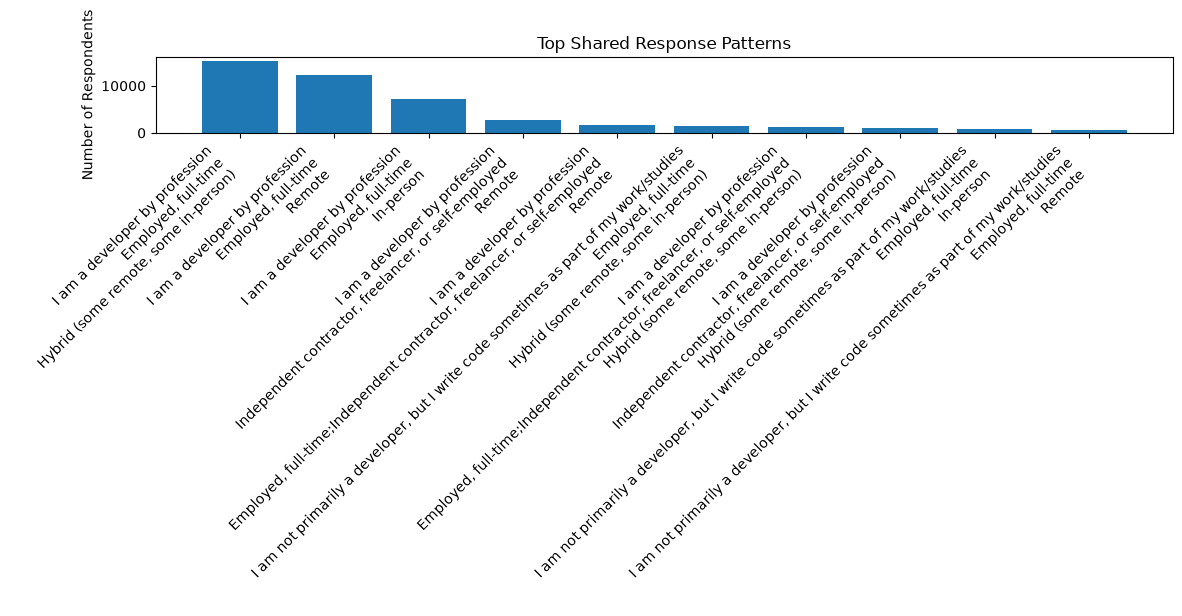

In [72]:
pattern_counts = (
    df.groupby(["MainBranch", "Employment", "RemoteWork"])
      .size()
      .reset_index(name="Respondents")
)


import matplotlib.pyplot as plt

top_patterns = pattern_counts.nlargest(10, "Respondents")
print(top_patterns)

labels = (
    top_patterns["MainBranch"]+ "\n"+top_patterns["Employment"]+ "\n" + top_patterns["RemoteWork"]
)

plt.figure(figsize=(12,6))
plt.bar(labels, top_patterns["Respondents"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Respondents")
plt.title("Top Shared Response Patterns")
plt.tight_layout()
plt.show()


                                                Country  \
4350                           United States of America   
4348                           United States of America   
1398                                            Germany   
4077                                            Ukraine   
4228  United Kingdom of Great Britain and Northern I...   

                          MainBranch           Employment  \
4350  I am a developer by profession  Employed, full-time   
4348  I am a developer by profession  Employed, full-time   
1398  I am a developer by profession  Employed, full-time   
4077  I am a developer by profession  Employed, full-time   
4228  I am a developer by profession  Employed, full-time   

                                RemoteWork  Respondents  
4350                                Remote         3304  
4348  Hybrid (some remote, some in-person)         2300  
1398  Hybrid (some remote, some in-person)         1534  
4077                                Remote    

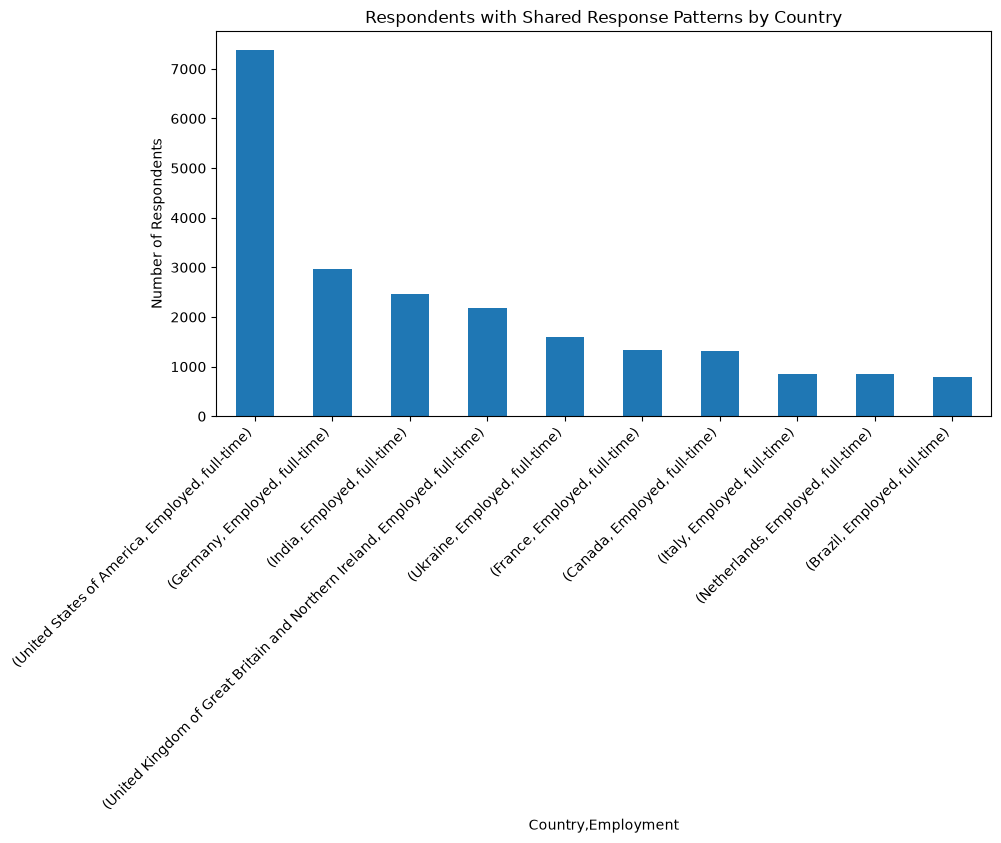

In [82]:
country_patterns = (
    df.groupby(["Country", "MainBranch", "Employment", "RemoteWork"])
      .size()
      .reset_index(name="Respondents").sort_values(by = "Respondents", ascending= False)
)
print(country_patterns.head(5))

country_summary = (
    country_patterns.groupby(["Country", "Employment"])["Respondents"]
                    .sum()
                    .sort_values(ascending=False)
                    .head(10)
)

print(country_summary)

country_summary.plot(
    kind="bar",
    figsize=(10,5),
    title="Respondents with Shared Response Patterns by Country"
)
plt.xticks(rotation = 45, ha="right")
plt.ylabel("Number of Respondents")
plt.show()

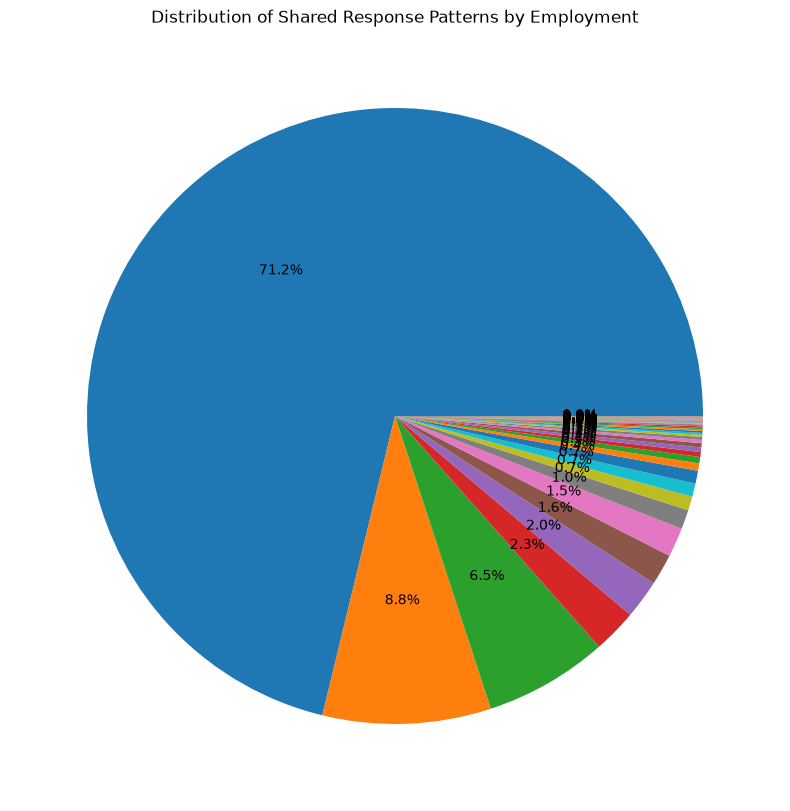

In [88]:
employment_summary = (
    pattern_counts.groupby("Employment")["Respondents"]
                  .sum()
                  .sort_values(ascending=False))

ax = employment_summary.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(20,10), labels = None,
    ylabel=""
)

"""
ax.legend(
    title="Employment",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
"""
plt.title("Distribution of Shared Response Patterns by Employment")
plt.show()


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
